**EX NO 4** **-** **Probabilistic Classification using Naïve Bayes**
**(Gaussian & Multinomial Naïve Bayes**)


DATE: 13.02.2026

Priyadharshini B - 24BAD093

Scenario 1- Classify SMS messages as Spam or Ham (Not Spam)

Accuracy : 0.9748743718592965
Precision: 0.9105263157894737
Recall   : 0.9057591623036649
F1 Score : 0.9081364829396326


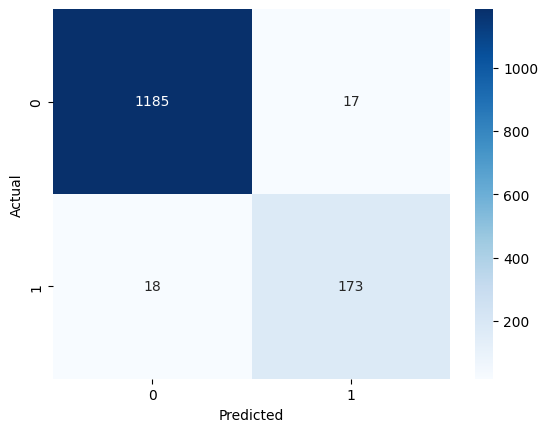

won
prize
reply
stop
text
claim
mobile
ur
txt
free


In [1]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

data = pd.read_csv("/content/spam.csv", encoding='latin-1')[['v1','v2']]
data.columns = ['label','message']

data['label'] = data['label'].map({'ham':0, 'spam':1})

def clean_text(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    return text

data['message'] = data['message'].apply(clean_text)

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['message'])
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

feature_names = vectorizer.get_feature_names_out()
spam_prob = model.feature_log_prob_[1]
top_words = np.argsort(spam_prob)[-10:]

for i in top_words:
    print(feature_names[i])

Scenario 2 - Classify flower species based on physical measurements

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



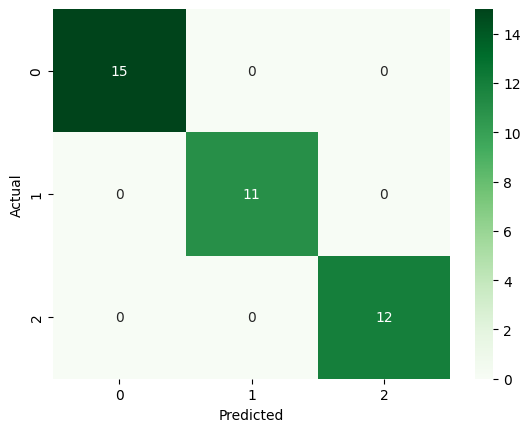

[[1.34177201e-094 9.95499547e-001 4.50045330e-003]
 [1.00000000e+000 1.45351958e-013 1.02352104e-020]
 [1.40585971e-302 6.04667443e-012 1.00000000e+000]
 [1.94541942e-097 9.76485329e-001 2.35146705e-002]
 [1.46080695e-110 8.51147237e-001 1.48852763e-001]]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

probs = model.predict_proba(X_test)
print(probs[:5])